# STAT 482 â€” EDA and Regression Analysis
**Authors:** Harsh Dave, Nick Griffin, Jack Leidlein, Hector Carrillo

This notebook reproduces the complete analysis pipeline for the STAT 482 project:
*Modeling the Effect of Pitch Sequencing and Batter-Specific Adjustments on Swing-and-Miss Outcomes in MLB*.

**Contents:**
1. Data Loading & Cleaning
2. Summary Statistics
3. Exploratory Data Analysis (Figures 1â€“5)
4. Baseline Logistic Regression (Eq. 2)
5. Sequencing Logistic Regression (Eq. 3)
6. Model Comparison: LRT & BIC
7. GLMM: Batter Random Intercepts (Eq. 4)
8. LaTeX Macro Values

In [34]:
%matplotlib inline
import os, sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pybaseball import statcast
from scipy import optimize, stats

sns.set_theme(style='whitegrid', font_scale=1.15)
PALETTE = sns.color_palette('colorblind')

In [35]:
# â”€â”€ Project paths â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Notebook lives in code/; project root is one level up.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
BUILD_DIR    = os.path.join(PROJECT_ROOT, 'build')
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data')
FIG_DIR      = os.path.join(BUILD_DIR, 'figures')
CACHE_FILE   = os.path.join(DATA_DIR, 'statcast_2025.csv')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(BUILD_DIR, exist_ok=True)
os.makedirs(FIG_DIR,  exist_ok=True)

# â”€â”€ Constants â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
PITCH_LABELS = {
    'FF': '4-Seam FB', 'SI': 'Sinker',       'FC': 'Cutter',
    'SL': 'Slider',    'ST': 'Sweeper',       'CU': 'Curveball',
    'KC': 'Knuckle-Curve', 'CH': 'Changeup', 'FS': 'Splitter',
}
KEEP_PITCH_TYPES  = set(PITCH_LABELS.keys())
WHIFF_DESCRIPTIONS = {'swinging_strike', 'swinging_strike_blocked', 'foul_tip'}
NON_COMPETITIVE   = {'pitchout', 'intent_ball', 'intentional_ball', 'pitchout_hit_into_play'}

## 1. Data Loading
We fetch 2025 MLB Statcast pitch-level data via `pybaseball`. On the first run this downloads ~700k pitches across the full regular season and caches the result to `data/statcast_2025.csv`.

In [36]:
def fetch_data():
    if os.path.exists(CACHE_FILE):
        print(f'[INFO] Loading cached data from {CACHE_FILE}')
        return pd.read_csv(CACHE_FILE, low_memory=False)
    print('[INFO] Fetching 2025 Statcast data (this may take several minutes)...')
    date_ranges = [
        ('2025-03-27', '2025-04-30'), ('2025-05-01', '2025-05-31'),
        ('2025-06-01', '2025-06-30'), ('2025-07-01', '2025-07-31'),
        ('2025-08-01', '2025-08-31'), ('2025-09-01', '2025-09-28'),
    ]
    chunks = []
    for start, end in date_ranges:
        print(f'  Fetching {start} to {end} ...')
        chunk = statcast(start_dt=start, end_dt=end)
        chunks.append(chunk)
        print(f'  -> {len(chunk):,} pitches')
    df = pd.concat(chunks, ignore_index=True)
    df.to_csv(CACHE_FILE, index=False)
    print(f'[INFO] Saved {len(df):,} raw pitches to {CACHE_FILE}')
    return df

raw = fetch_data()
print(f'Raw rows: {len(raw):,}')

[INFO] Loading cached data from c:\Users\ngrif\Documents\STAT482\data\statcast_2025.csv
Raw rows: 711,897


## 2. Data Cleaning
Cleaning steps used in the project report:
1. Remove non-competitive events (pitchouts, intentional balls)
2. Drop pitches with missing physical measurements
3. Filter unrealistic release speeds (outside 65â€“105 mph)
4. Keep only the 9 main pitch types
5. Derive movement in inches and binary whiff indicator
6. Build lag variables within each plate appearance

In [37]:
def classify_outcome(desc):
    if pd.isna(desc):              return 'None'
    if 'ball' in desc and 'foul' not in desc: return 'Ball'
    if 'called_strike' in desc:    return 'Called Strike'
    if 'swinging_strike' in desc:  return 'Swinging Strike'
    if 'foul' in desc:             return 'Foul'
    if 'hit_into_play' in desc:    return 'In Play'
    return 'Other'

def clean_data(raw):
    n_raw = len(raw)
    df = raw.copy()

    # 1. Non-competitive
    df = df[~df['description'].isin(NON_COMPETITIVE)]
    df = df[~df['pitch_type'].isin(['PO', 'IN'])]
    print(f'  After non-competitive filter:    {len(df):,}')

    # 2. Missing physics
    df = df.dropna(subset=['release_speed', 'pfx_x', 'pfx_z', 'release_extension'])
    print(f'  After dropping missing physics:  {len(df):,}')

    # 3. Speed filter
    df = df[(df['release_speed'] >= 65) & (df['release_speed'] <= 105)]
    # 4. Pitch types
    df = df[df['pitch_type'].isin(KEEP_PITCH_TYPES)]
    print(f'  After speed & pitch-type filter: {len(df):,}')

    # 5. Derived columns
    df['pitch_label'] = df['pitch_type'].map(PITCH_LABELS)
    df['ivb_inches']  = df['pfx_z'] * 12
    df['hb_inches']   = df['pfx_x'] * 12
    df['whiff']       = df['description'].isin(WHIFF_DESCRIPTIONS).astype(int)

    # 6. Lag variables
    df = df.sort_values(['game_pk', 'at_bat_number', 'pitch_number'])
    grp = df.groupby(['game_pk', 'at_bat_number'])
    df['prev_pitch_type']  = grp['pitch_type'].shift(1).fillna('None')
    df['prev_pitch_label'] = df['prev_pitch_type'].map(lambda x: PITCH_LABELS.get(x, 'None'))
    df['prev_zone']        = grp['zone'].shift(1).fillna(-1).astype(int)
    df['prev_outcome']     = grp['description'].shift(1).apply(classify_outcome)

    print(f'\nFinal cleaned dataset: {len(df):,} pitches')
    return df, n_raw

df, n_raw = clean_data(raw)

  After non-competitive filter:    711,843
  After dropping missing physics:  709,057
  After speed & pitch-type filter: 702,321

Final cleaned dataset: 702,321 pitches


## 3. Summary Statistics

In [38]:
overall_whiff = df['whiff'].mean() * 100
batter_whiffs = df.groupby('batter').agg(n=('whiff','size'), rate=('whiff','mean'))
batter_200    = batter_whiffs[batter_whiffs['n'] >= 200]
batter_rates  = batter_200['rate'] * 100

print(f'Total raw pitches:    {n_raw:,}')
print(f'Cleaned pitches:      {len(df):,}')
print(f'Overall whiff rate:   {overall_whiff:.1f}%')
print(f'Unique batters (>=200 pitches): {len(batter_200)}')
print(f'Unique pitchers:      {df["pitcher"].nunique()}')
print(f'Batter whiff range:   {batter_rates.min():.1f}% â€“ {batter_rates.max():.1f}%')

print('\nPhysical characteristics summary:')
phys = {'Release Speed (mph)': df['release_speed'],
        'IVB (in.)':           df['ivb_inches'],
        'HB (in.)':            df['hb_inches'],
        'Extension (ft)':      df['release_extension']}
for name, col in phys.items():
    print(f'  {name:25s}  mean={col.mean():.1f}  sd={col.std():.1f}  '
          f'[{col.min():.1f}, {col.max():.1f}]')

print('\nWhiff rate by pitch type:')
wt = df.groupby('pitch_label').agg(n=('whiff','size'), w=('whiff','sum'))
wt['rate'] = wt['w'] / wt['n'] * 100
print(wt.sort_values('rate', ascending=False).to_string())

Total raw pitches:    711,897
Cleaned pitches:      702,321
Overall whiff rate:   12.0%
Unique batters (>=200 pitches): 531
Unique pitchers:      811
Batter whiff range:   2.4% â€“ 23.2%

Physical characteristics summary:
  Release Speed (mph)        mean=89.5  sd=5.8  [65.2, 104.2]
  IVB (in.)                  mean=6.9  sd=8.6  [-24.0, 27.5]
  HB (in.)                   mean=-1.6  sd=10.8  [-29.4, 30.5]
  Extension (ft)             mean=6.4  sd=0.4  [3.9, 9.6]

Whiff rate by pitch type:
                    n      w       rate
pitch_label                            
Splitter        23155   4154  17.939970
Slider         103611  16816  16.229937
Knuckle-Curve   12647   2033  16.074958
Changeup        72959  11337  15.538864
Sweeper         52305   7472  14.285441
Curveball       47617   6088  12.785350
Cutter          53540   5873  10.969369
4-Seam FB      225924  23820  10.543369
Sinker         110563   6958   6.293245


## 4. Exploratory Data Analysis
Figures are saved to `figures/` and also displayed inline below.

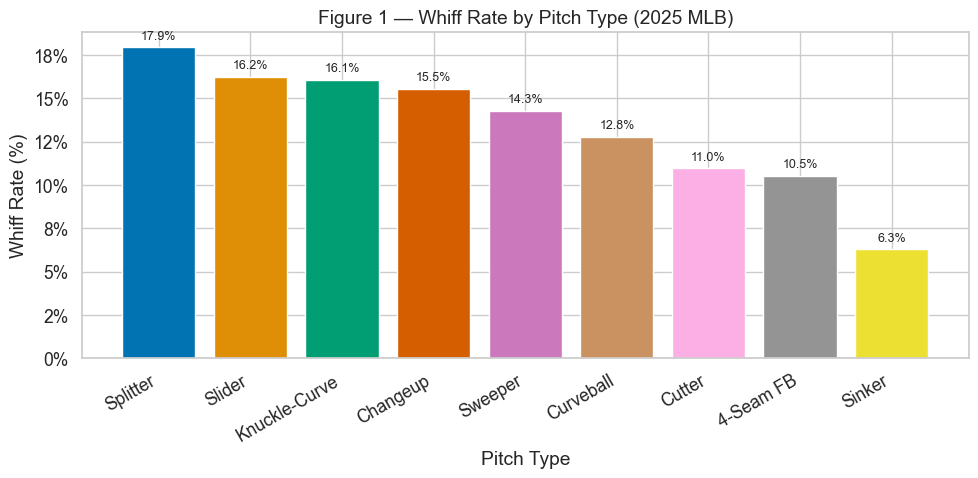

In [39]:
# Figure 1 â€” Whiff rate by pitch type
rates = df.groupby('pitch_label')['whiff'].mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(rates.index, rates.values, color=PALETTE[:len(rates)], edgecolor='white')
for bar, val in zip(bars, rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Whiff Rate (%)')
ax.set_xlabel('Pitch Type')
ax.set_title('Figure 1 â€” Whiff Rate by Pitch Type (2025 MLB)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_whiff_by_pitch_type.png'), dpi=200)
plt.show()

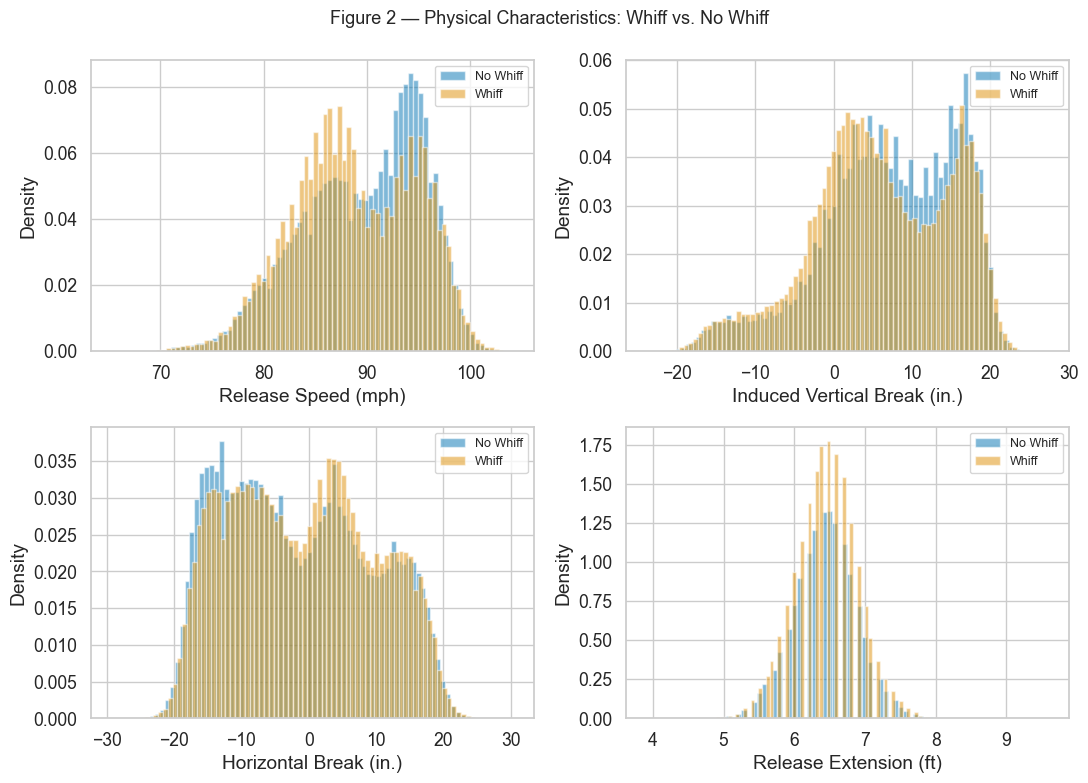

In [40]:
# Figure 2 â€” Physical distributions by whiff outcome
cols  = ['release_speed', 'ivb_inches', 'hb_inches', 'release_extension']
names = ['Release Speed (mph)', 'Induced Vertical Break (in.)',
         'Horizontal Break (in.)', 'Release Extension (ft)']
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col, name in zip(axes.flat, cols, names):
    for label, color in [('No Whiff', PALETTE[0]), ('Whiff', PALETTE[1])]:
        subset = df[df['whiff'] == (1 if label == 'Whiff' else 0)]
        ax.hist(subset[col], bins=80, density=True, alpha=0.5, label=label, color=color)
    ax.set_xlabel(name)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
fig.suptitle('Figure 2 â€” Physical Characteristics: Whiff vs. No Whiff', fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_physical_distributions.png'), dpi=200, bbox_inches='tight')
plt.show()

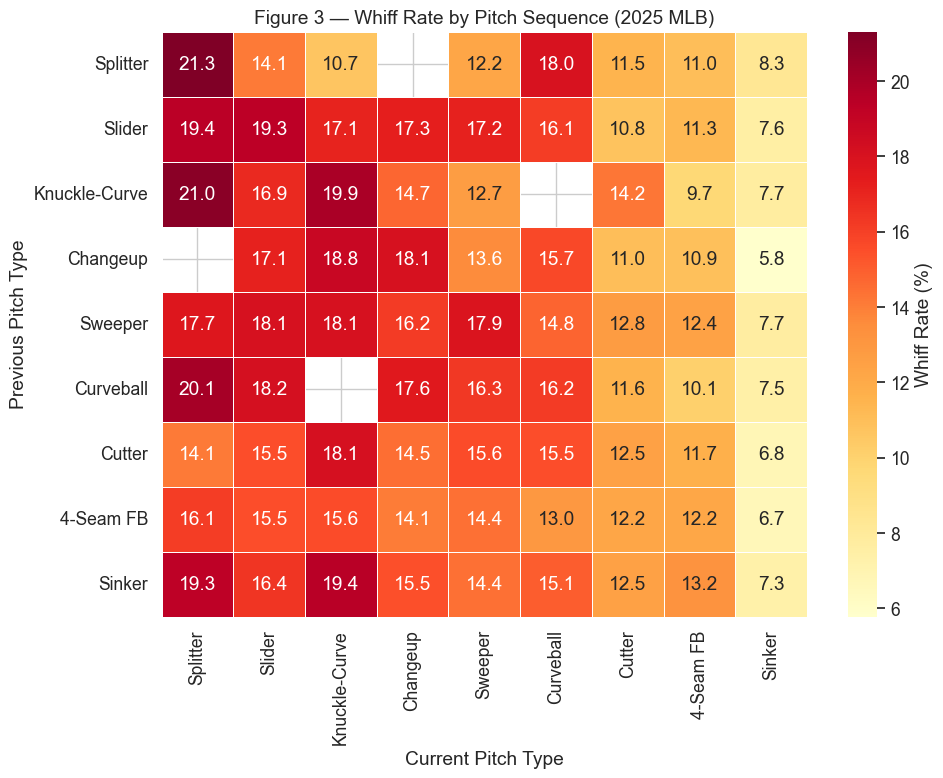

In [41]:
# Figure 3 â€” Sequence heatmap
seq = df[df['prev_pitch_label'] != 'None'].copy()
ct  = seq.groupby(['prev_pitch_label', 'pitch_label']).agg(
    n=('whiff','size'), whiffs=('whiff','sum')).reset_index()
ct['rate'] = ct['whiffs'] / ct['n'] * 100
ct = ct[ct['n'] >= 100]
pivot = ct.pivot(index='prev_pitch_label', columns='pitch_label', values='rate')
order = df.groupby('pitch_label')['whiff'].mean().sort_values(ascending=False).index.tolist()
order = [o for o in order if o in pivot.columns]
pivot = pivot.reindex(index=[o for o in order if o in pivot.index], columns=order)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Whiff Rate (%)'})
ax.set_xlabel('Current Pitch Type')
ax.set_ylabel('Previous Pitch Type')
ax.set_title('Figure 3 â€” Whiff Rate by Pitch Sequence (2025 MLB)')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_sequence_heatmap.png'), dpi=200)
plt.show()

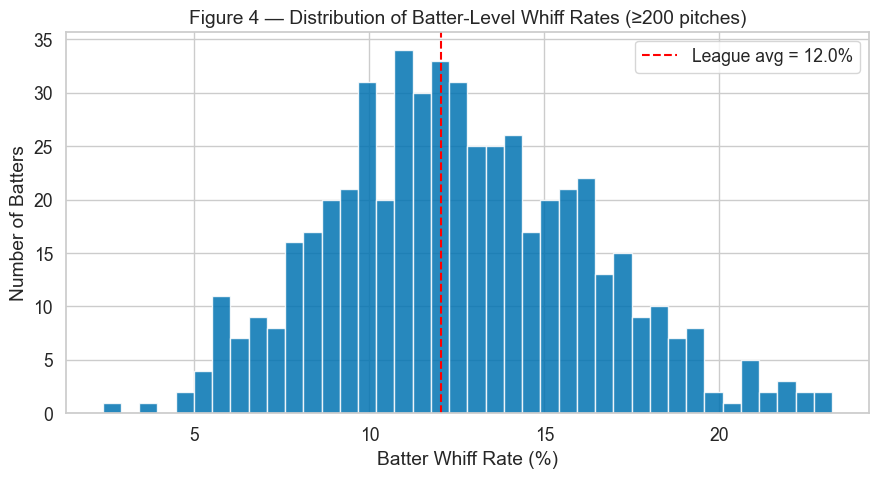

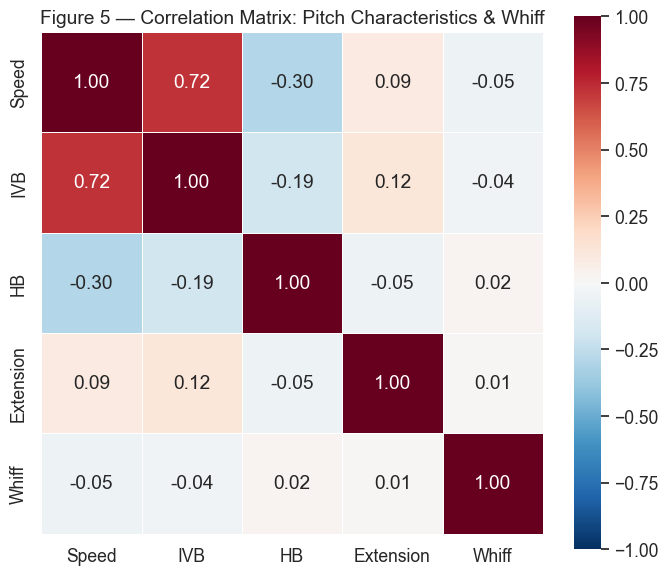

In [42]:
# Figure 4 â€” Batter whiff distribution
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(batter_rates, bins=40, color=PALETTE[0], edgecolor='white', alpha=0.85)
ax.axvline(overall_whiff, color='red', linestyle='--', linewidth=1.5,
           label=f'League avg = {overall_whiff:.1f}%')
ax.set_xlabel('Batter Whiff Rate (%)')
ax.set_ylabel('Number of Batters')
ax.set_title('Figure 4 â€” Distribution of Batter-Level Whiff Rates (â‰¥200 pitches)')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_batter_whiff_dist.png'), dpi=200)
plt.show()

# Figure 5 â€” Correlation matrix
corr_cols   = ['release_speed', 'ivb_inches', 'hb_inches', 'release_extension', 'whiff']
corr_labels = ['Speed', 'IVB', 'HB', 'Extension', 'Whiff']
corr = df[corr_cols].corr()
corr.index = corr.columns = corr_labels
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5, square=True, ax=ax)
ax.set_title('Figure 5 â€” Correlation Matrix: Pitch Characteristics & Whiff')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_correlation_matrix.png'), dpi=200)
plt.show()

## 5. Logistic Regression Models

We implement two logistic regression models using maximum likelihood estimation (Newton-Raphson / L-BFGS-B), replicating what `glm(..., family=binomial)` in R would produce.

**Baseline (Eq. 2):** Physical characteristics only
$$\text{logit}(p_i) = \beta X_i, \quad X_i = [\text{Speed, IVB, HB, Ext}]$$

**Sequencing (Eq. 3):** Physical + lagged pitch context
$$\text{logit}(p_i) = \beta X_i + \gamma Z_{i-1} + \alpha(T_i \times T_{i-1})$$

In [43]:
# â”€â”€ MLE helpers â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def _sigmoid(z):
    return np.where(z >= 0, 1.0/(1.0+np.exp(-z)), np.exp(z)/(1.0+np.exp(z)))

def _neg_loglik(beta, X, y):
    p = np.clip(_sigmoid(X @ beta), 1e-12, 1-1e-12)
    return -np.sum(y*np.log(p) + (1-y)*np.log(1-p))

def _neg_loglik_grad(beta, X, y):
    return X.T @ (_sigmoid(X @ beta) - y)

def _fit_logistic(X, y):
    result = optimize.minimize(
        _neg_loglik, np.zeros(X.shape[1]), args=(X, y),
        jac=_neg_loglik_grad, method='L-BFGS-B',
        options={'maxiter': 2000, 'ftol': 1e-12, 'gtol': 1e-8})
    beta_hat = result.x
    p_hat = _sigmoid(X @ beta_hat)
    w = np.clip(p_hat * (1 - p_hat), 1e-10, None)
    try:
        se = np.sqrt(np.diag(np.linalg.inv((X * w[:, None]).T @ X)))
    except np.linalg.LinAlgError:
        se = np.sqrt(np.abs(np.diag(np.linalg.pinv((X * w[:, None]).T @ X))))
    return beta_hat, se, -result.fun, result.success

def _dummy_encode(df, col, drop_first=True):
    return pd.get_dummies(df[col], prefix=col, drop_first=drop_first, dtype=float)

def _bin_zone(zone):
    if zone == -1 or pd.isna(zone): return 'None'
    z = int(zone)
    if z == 5:           return 'Heart'
    if 1 <= z <= 9:      return 'Strike'
    if 11 <= z <= 14:    return 'Chase'
    return 'None'

### 5.1 Data Preparation
We add `prev_zone_cat` and the currentÃ—previous pitch-type interaction `pitch_seq_filtered`, then build design matrices.

In [44]:
PHYS = ['release_speed', 'ivb_inches', 'hb_inches', 'release_extension']

df2 = df.copy()
df2['prev_zone_cat'] = df2['prev_zone'].apply(_bin_zone)
df2['pitch_seq']     = df2['prev_pitch_label'] + '__' + df2['pitch_label']

# Sequencing dataset: exclude first pitches of each PA
seq_df = df2[(df2['prev_pitch_label'] != 'None') & df2[PHYS].notna().all(axis=1)].copy()
print(f'Sequencing dataset: {len(seq_df):,} pitches')

# Collapse sequences with < 100 obs
MIN_SEQ_OBS = 100
seq_counts  = seq_df['pitch_seq'].value_counts()
common_seqs = seq_counts[seq_counts >= MIN_SEQ_OBS].index
seq_df['pitch_seq_filtered'] = np.where(
    seq_df['pitch_seq'].isin(common_seqs), seq_df['pitch_seq'], 'Other__Other')
print(f'Sequences >= {MIN_SEQ_OBS} obs: {len(common_seqs)} of {len(seq_counts)} unique')

# Dummy-encode categoricals
dum_type    = _dummy_encode(seq_df, 'prev_pitch_label')
dum_zone    = _dummy_encode(seq_df, 'prev_zone_cat')
dum_outcome = _dummy_encode(seq_df, 'prev_outcome')
dum_seq     = _dummy_encode(seq_df, 'pitch_seq_filtered')

# Standardise physical predictors
mu  = seq_df[PHYS].mean()
sd  = seq_df[PHYS].std().replace(0, 1)
phys_z = ((seq_df[PHYS] - mu) / sd).reset_index(drop=True)

seq_feat = pd.concat([phys_z,
                      dum_type.reset_index(drop=True),
                      dum_zone.reset_index(drop=True),
                      dum_outcome.reset_index(drop=True),
                      dum_seq.reset_index(drop=True)], axis=1)

y = seq_df['whiff'].to_numpy(dtype=np.float64)

# Add intercept column
ones = np.ones((len(y), 1))
X_base = np.column_stack([ones, phys_z.to_numpy(dtype=np.float64)])
X_seq  = np.column_stack([ones, seq_feat.to_numpy(dtype=np.float64)])
print(f'Baseline design matrix:   {X_base.shape}')
print(f'Sequencing design matrix: {X_seq.shape}')

Sequencing dataset: 520,559 pitches
Sequences >= 100 obs: 77 of 81 unique
Baseline design matrix:   (520559, 5)
Sequencing design matrix: (520559, 96)


### 5.2 Fit Models

In [45]:
print('Fitting Baseline model (Eq. 2)...')
beta_base, se_base, ll_base, conv_base = _fit_logistic(X_base, y)
print(f'  Log-likelihood: {ll_base:,.2f}  |  Converged: {conv_base}')

print('Fitting Sequencing model (Eq. 3)...')
beta_seq, se_seq, ll_seq, conv_seq = _fit_logistic(X_seq, y)
print(f'  Log-likelihood: {ll_seq:,.2f}  |  Converged: {conv_seq}')

Fitting Baseline model (Eq. 2)...
  Log-likelihood: -203,264.99  |  Converged: True
Fitting Sequencing model (Eq. 3)...
  Log-likelihood: -200,685.21  |  Converged: True


### 5.3 Model Comparison: LRT & BIC

In [46]:
n_obs    = len(y)
df_diff  = X_seq.shape[1] - X_base.shape[1]
lr_stat  = 2.0 * (ll_seq - ll_base)
lr_pval  = stats.chi2.sf(lr_stat, df=df_diff)
bic_base = -2*ll_base + X_base.shape[1]*np.log(n_obs)
bic_seq  = -2*ll_seq  + X_seq.shape[1]*np.log(n_obs)
delta_bic = bic_seq - bic_base

print(f'[LRT]  LR statistic  = {lr_stat:,.2f}  (df = {df_diff})')
print(f'[LRT]  p-value       = {lr_pval:.2e}')
print(f'[BIC]  Baseline:     {bic_base:,.2f}  (k = {X_base.shape[1]})')
print(f'[BIC]  Sequencing:   {bic_seq:,.2f}  (k = {X_seq.shape[1]})')
print(f'[BIC]  Î”BIC          = {delta_bic:,.2f}')
if delta_bic < -10:
    print('-> Strong evidence favouring the Sequencing model (Î”BIC < -10).')
elif delta_bic < 0:
    print('-> Sequencing model preferred; evidence is modest.')
else:
    print('-> Baseline preferred on BIC.')

[LRT]  LR statistic  = 5,159.57  (df = 91)
[LRT]  p-value       = 0.00e+00
[BIC]  Baseline:     406,595.79  (k = 5)
[BIC]  Sequencing:   402,634.03  (k = 96)
[BIC]  Î”BIC          = -3,961.77
-> Strong evidence favouring the Sequencing model (Î”BIC < -10).


### 5.4 Coefficient Tables

In [47]:
# Baseline model table
base_names = ['Intercept'] + [f'{c}_z' for c in PHYS]
z_base = beta_base / se_base
p_base = 2.0 * stats.norm.sf(np.abs(z_base))
base_tbl = pd.DataFrame({'Coef': beta_base, 'SE': se_base, 'z': z_base, 'p': p_base},
                        index=base_names)
base_tbl['Sig'] = base_tbl['p'].apply(
    lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '')))
print('=== BASELINE MODEL (Eq. 2) ===')
print(base_tbl.to_string(float_format='{:.4f}'.format))

=== BASELINE MODEL (Eq. 2) ===
                       Coef     SE         z      p  Sig
Intercept           -1.8845 0.0041 -457.7548 0.0000  ***
release_speed_z     -0.1037 0.0059  -17.4903 0.0000  ***
ivb_inches_z        -0.0563 0.0058   -9.7430 0.0000  ***
hb_inches_z          0.0330 0.0042    7.8000 0.0000  ***
release_extension_z  0.0484 0.0041   11.7643 0.0000  ***


In [48]:
# Sequencing model â€” top terms by |z|
seq_names = ['Intercept'] + seq_feat.columns.tolist()
z_seq = beta_seq / se_seq
p_seq = 2.0 * stats.norm.sf(np.abs(z_seq))
seq_tbl = pd.DataFrame({'Coef': beta_seq, 'SE': se_seq, 'z': z_seq, 'p': p_seq},
                       index=seq_names)
seq_tbl['Sig'] = seq_tbl['p'].apply(
    lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '')))
# Show top 25 sequencing terms by |z|
phys_set = {'Intercept'} | set([f'{c}_z' for c in PHYS])
seq_only = seq_tbl[~seq_tbl.index.isin(phys_set)].sort_values('z', key=np.abs, ascending=False)
print('=== SEQUENCING MODEL â€” Top 25 terms (|z| ranked) ===')
print(seq_only.head(25).to_string(float_format='{:.4f}'.format))

=== SEQUENCING MODEL â€” Top 25 terms (|z| ranked) ===
                                               Coef          SE        z      p  Sig
pitch_seq_filtered_4-Seam FB__Slider         0.5084      0.0272  18.7025 0.0000  ***
release_speed                                0.1534      0.0082  18.7021 0.0000  ***
pitch_seq_filtered_4-Seam FB__Changeup       0.4230      0.0286  14.7651 0.0000  ***
pitch_seq_filtered_4-Seam FB__Splitter       0.5726      0.0391  14.6284 0.0000  ***
pitch_seq_filtered_4-Seam FB__Sinker        -0.6051      0.0416 -14.5429 0.0000  ***
pitch_seq_filtered_4-Seam FB__Sweeper        0.5095      0.0376  13.5364 0.0000  ***
prev_outcome_Swinging Strike                 0.1840      0.0150  12.2700 0.0000  ***
pitch_seq_filtered_4-Seam FB__Knuckle-Curve  0.6127      0.0563  10.8781 0.0000  ***
pitch_seq_filtered_4-Seam FB__Curveball      0.4667      0.0441  10.5877 0.0000  ***
release_extension                            0.0354      0.0042   8.4676 0.0000  ***
hb_inches 

## 7. GLMM: Batter Random Intercepts (Eq. 4)

We extend the sequencing model with a batter-level random intercept fitted via MAP estimation (`statsmodels.BinomialBayesMixedGLM`). Each batter gets their own baseline whiff probability â€” controlling for individual tendencies without consuming 500+ degrees of freedom on fixed dummies.

In [51]:
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
from scipy import sparse as sp

# Subsample for speed
np.random.seed(42)
glmm_df = seq_df.sample(n=min(30000, len(seq_df)), random_state=42).copy().reset_index(drop=True)

# Standardised physical columns (same mu/sd from Section 5.1)
for col in PHYS:
    glmm_df[col + '_z'] = (glmm_df[col] - mu[col]) / sd[col]

# Fixed effects design matrix (same structure as sequencing model)
glmm_phys_z = pd.DataFrame({col + '_z': glmm_df[col + '_z'] for col in PHYS})
glmm_feat = pd.concat([
    glmm_phys_z,
    _dummy_encode(glmm_df, 'prev_pitch_label').reset_index(drop=True),
    _dummy_encode(glmm_df, 'prev_zone_cat').reset_index(drop=True),
    _dummy_encode(glmm_df, 'prev_outcome').reset_index(drop=True),
    _dummy_encode(glmm_df, 'pitch_seq_filtered').reset_index(drop=True),
], axis=1)
X_glmm = np.column_stack([np.ones(len(glmm_df)), glmm_feat.to_numpy(dtype=np.float64)])
y_glmm = glmm_df['whiff'].to_numpy(dtype=np.float64)

# Batter indicator matrix (dense) â€” one column per batter, random intercepts
batter_codes, batter_uniq = pd.factorize(glmm_df['batter'])
n_batters = len(batter_uniq)
Z_batter  = sp.csc_matrix(
    (np.ones(len(glmm_df)), (np.arange(len(glmm_df)), batter_codes)),
    shape=(len(glmm_df), n_batters)
).toarray()
ident = np.zeros(n_batters, dtype=int)

print(f'GLMM: {len(glmm_df):,} obs, {n_batters} batters, {X_glmm.shape[1]} fixed effects')
print('Fitting via variational Bayes...')
glmm_model  = BinomialBayesMixedGLM(y_glmm, X_glmm, Z_batter, ident)
glmm_result = glmm_model.fit_vb()
print(glmm_result.summary())

# Variance component: vcp_mean holds log(sigma^2) for each random effect group
sigma_batter  = np.exp(glmm_result.vcp_mean[0])  # vcp_mean = log(sigma)
sigma2_batter = sigma_batter ** 2
icc           = sigma2_batter / (sigma2_batter + (np.pi**2 / 3))

print('')
print(f'Batter random intercept  sigma  = {sigma_batter:.4f}')
print(f'Batter random intercept  sigma2 = {sigma2_batter:.4f}')
print(f'ICC (batter)                    = {icc:.4f}')
print(f'  -> {icc*100:.1f}% of log-odds variance is between-batter')

GLMM: 30,000 obs, 649 batters, 96 fixed effects
Fitting via variational Bayes...
             Binomial Mixed GLM Results
      Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
----------------------------------------------------
FE_1     M    -2.1496   0.0173                      
FE_2     M     0.1828   0.0173                      
FE_3     M    -0.0686   0.0168                      
FE_4     M     0.0575   0.0175                      
FE_5     M     0.0270   0.0173                      
FE_6     M     0.3762   0.0552                      
FE_7     M     0.1739   0.0683                      
FE_8     M     0.1233   0.0611                      
FE_9     M    -0.0733   0.1276                      
FE_10    M     0.3687   0.0453                      
FE_11    M     0.2655   0.0435                      
FE_12    M    -0.1377   0.0913                      
FE_13    M     0.2787   0.0617                      
FE_14    M    -0.0819   0.0700                      
FE_15    M     0.0159   0.0271 

## 8. LaTeX Macro Values
Copy these into `Report2.tex`.

In [52]:
print('% â”€â”€ Paste into Report2.tex â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€')
print(f'\\newcommand{{\\seqLLBase}}     {{{ll_base:,.2f}}}')
print(f'\\newcommand{{\\seqLLSeq}}      {{{ll_seq:,.2f}}}')
print(f'\\newcommand{{\\seqLRStat}}     {{{lr_stat:,.2f}}}')
print(f'\\newcommand{{\\seqLRDf}}       {{{df_diff}}}')
print(f'\\newcommand{{\\seqLRPval}}     {{{lr_pval:.2e}}}')
print(f'\\newcommand{{\\seqBICBase}}    {{{bic_base:,.2f}}}')
print(f'\\newcommand{{\\seqBICSeq}}     {{{bic_seq:,.2f}}}')
print(f'\\newcommand{{\\seqDeltaBIC}}   {{{delta_bic:,.2f}}}')

% â”€â”€ Paste into Report2.tex â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
\newcommand{\seqLLBase}     {-203,264.99}
\newcommand{\seqLLSeq}      {-200,685.21}
\newcommand{\seqLRStat}     {5,159.57}
\newcommand{\seqLRDf}       {91}
\newcommand{\seqLRPval}     {0.00e+00}
\newcommand{\seqBICBase}    {406,595.79}
\newcommand{\seqBICSeq}     {402,634.03}
\newcommand{\seqDeltaBIC}   {-3,961.77}
